⏳ Running Pure Genetic Algorithm for Feature Selection...
✅ Pure GA completed in 621.65 seconds
✅ Pure GA Selected 24 Features:
['Src_Port', 'TotLen_Bwd_Pkts', 'Fwd_Pkt_Len_Std', 'Bwd_Pkt_Len_Min', 'Bwd_Pkt_Len_Mean', 'Bwd_Pkt_Len_Std', 'Fwd_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_IAT_Max', 'Fwd_Header_Len', 'Bwd_Header_Len', 'Fwd_Pkts/s', 'Bwd_Pkts/s', 'Pkt_Len_Min', 'Pkt_Len_Mean', 'Pkt_Len_Std', 'Pkt_Len_Var', 'SYN_Flag_Cnt', 'CWE_Flag_Count', 'Fwd_Blk_Rate_Avg', 'Bwd_Byts/b_Avg', 'Subflow_Fwd_Byts', 'Subflow_Bwd_Pkts', 'Active_Max']

📊 Classification Report (Pure GA Selected Features):


🧠 Model: Random Forest
🔹 Train Accuracy: 0.9928
🔹 Test Accuracy : 0.9396
🔸 Classification Report (Test):
                   precision    recall  f1-score   support

              DoS       1.00      1.00      1.00     11872
MITM ARP Spoofing       0.70      0.82      0.75      3009
            Mirai       0.97      0.94      0.96     28667
           Normal       0.97      0.94      0.95      5506
         

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.992751,0.939590,0.053161
MLP,0.895805,0.872278,0.023527
KNN,0.939679,0.918083,0.021596
XGBoost,0.937682,0.922155,0.015527


<Figure size 1000x600 with 0 Axes>

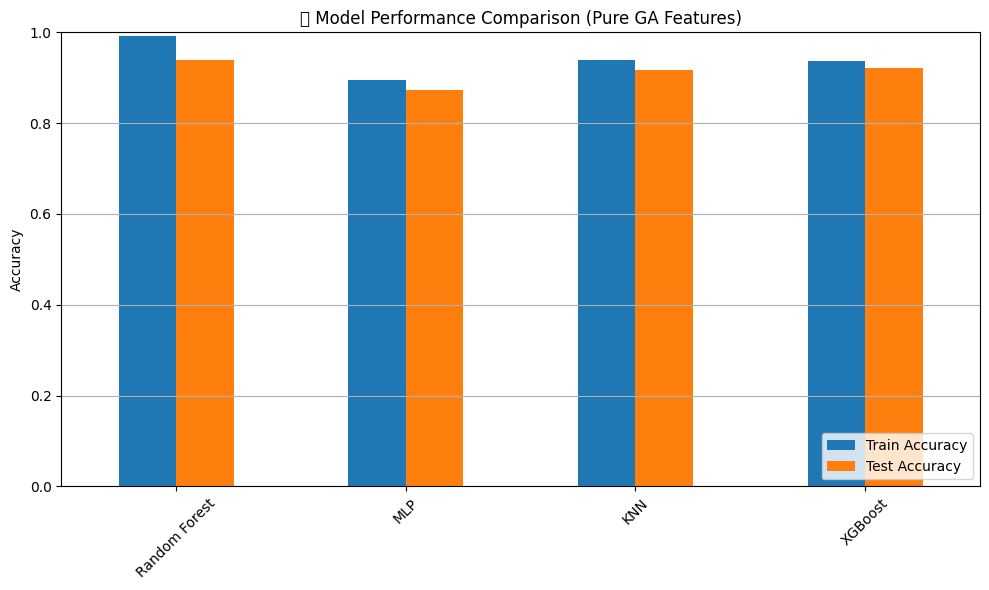

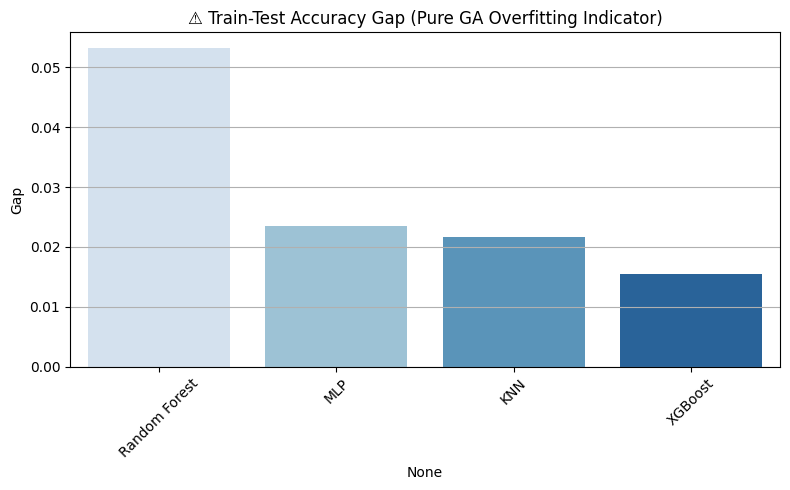

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms
import random
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Ensure creator classes are not redefined if the cell is run multiple times
# Use unique names for the pure GA setup
try:
    del creator.FitnessMax_PureGA
    del creator.Individual_PureGA
except AttributeError:
    pass

# --- Step 1: Define the full set of features for the GA to choose from ---
# In a pure GA approach, we start with all available features
all_features = X.columns # X is the original feature set before splitting
N_FEATURES = len(all_features) # Total number of features

# --- Step 2: Genetic Algorithm Setup (Pure GA) ---

# This K now represents the desired number of features from the *entire* dataset
K = 10 # You can adjust this desired number of features

# Define fitness and individual types for DEAP
# Using unique names to avoid conflicts if the previous GA cell was also run
creator.create("FitnessMax_PureGA", base.Fitness, weights=(1.0,))
creator.create("Individual_PureGA", list, fitness=creator.FitnessMax_PureGA)

toolbox_pure_ga = base.Toolbox()
toolbox_pure_ga.register("attr_bool", random.randint, 0, 1)
# Individual length is now N_FEATURES, representing all available features
toolbox_pure_ga.register("individual", tools.initRepeat, creator.Individual_PureGA, toolbox_pure_ga.attr_bool, n=N_FEATURES)
toolbox_pure_ga.register("population", tools.initRepeat, list, toolbox_pure_ga.individual)

def get_fitness_pure_ga(individual):
    if sum(individual) == 0: # If no features are selected
        return 0.,

    idx = [i for i, bit in enumerate(individual) if bit == 1]
    # Use the full balanced training data, selecting columns based on 'idx'
    X_sub = X_train_bal.iloc[:, idx]

    clf = DecisionTreeClassifier(max_depth=6, random_state=42) # Shallower DT for speed
    # Check if there are enough samples and classes for cross_val_score
    if X_sub.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
        scores = cross_val_score(clf, X_sub, y_train_bal, cv=2, scoring='accuracy') # Faster CV
        acc = scores.mean()
    else:
        acc = 0.0 # Return 0 accuracy if data is insufficient

    penalty = 0.01 * (sum(individual) - K) ** 2 # Penalty for deviating from K features
    return acc - penalty,

toolbox_pure_ga.register("evaluate", get_fitness_pure_ga)
toolbox_pure_ga.register("mate", tools.cxTwoPoint)
toolbox_pure_ga.register("mutate", tools.mutFlipBit, indpb=0.1) # Probability of a bit flipping
toolbox_pure_ga.register("select", tools.selTournament, tournsize=2) # Tournament selection

pop_pure_ga = toolbox_pure_ga.population(n=15) # Initial population size
hof_pure_ga = tools.HallOfFame(1) # To store the best individual found

start = time.time()
print("⏳ Running Pure Genetic Algorithm for Feature Selection...")
# More generations might be needed for a larger feature space, adjust ngen if necessary
algorithms.eaSimple(pop_pure_ga, toolbox_pure_ga, cxpb=0.5, mutpb=0.3, ngen=10, halloffame=hof_pure_ga, verbose=False)
end = time.time()
print(f"✅ Pure GA completed in {(end - start):.2f} seconds")

# Selected Features
selected_idx_pure_ga = [i for i, bit in enumerate(hof_pure_ga[0]) if bit == 1]
# Map selected indices back to original feature names
selected_features_pure_ga = all_features[selected_idx_pure_ga].tolist()
print(f"✅ Pure GA Selected {len(selected_features_pure_ga)} Features:\n{selected_features_pure_ga}")

# Final selected feature dataset
X_train_sel_pure_ga = X_train_bal[selected_features_pure_ga]
X_test_sel_pure_ga = X_test[selected_features_pure_ga]

# Scale features for models that require it (e.g., MLP, KNN)
scaler_pure_ga = StandardScaler()
X_train_sel_scaled_pure_ga = scaler_pure_ga.fit_transform(X_train_sel_pure_ga)
X_test_sel_scaled_pure_ga = scaler_pure_ga.transform(X_test_sel_pure_ga)

# Re-define models here for clarity or use the existing 'models' dict
# (Assuming 'models' dict and 'le' (LabelEncoder) from previous cells are accessible)
models_pure_ga = {
    'Random Forest': RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42, early_stopping=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
}

pure_ga_results = {}
print("\n📊 Classification Report (Pure GA Selected Features):\n")

for name, model in models_pure_ga.items():
    if name == "MLP":
        model.fit(X_train_sel_scaled_pure_ga, y_train_bal)
        y_train_pred = model.predict(X_train_sel_scaled_pure_ga)
        y_test_pred = model.predict(X_test_sel_scaled_pure_ga)
    else:
        model.fit(X_train_sel_pure_ga, y_train_bal)
        y_train_pred = model.predict(X_train_sel_pure_ga)
        y_test_pred = model.predict(X_test_sel_pure_ga)

    train_acc = accuracy_score(y_train_bal, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    pure_ga_results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Classification Report": classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_], output_dict=True)
    }

    print(f"\n🧠 Model: {name}")
    print(f"🔹 Train Accuracy: {train_acc:.4f}")
    print(f"🔹 Test Accuracy : {test_acc:.4f}")
    print("🔸 Classification Report (Test):")
    print(classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_]))

# Create Overfitting Gap Table
overfit_df_pure_ga = pd.DataFrame({
    model: {
        "Train Accuracy": vals["Train Accuracy"],
        "Test Accuracy": vals["Test Accuracy"],
        "Gap": vals["Train Accuracy"] - vals["Test Accuracy"]
    }
    for model, vals in pure_ga_results.items()
}).T

print("\n📉 Overfitting Check (Train-Test Accuracy Gap for Pure GA):")
display(overfit_df_pure_ga.sort_values(by="Gap", ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

# Barplot of Train/Test Accuracy
plt.figure(figsize=(10,6))
overfit_df_pure_ga[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(10,6))
plt.title("🔍 Model Performance Comparison (Pure GA Features)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Gap Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=overfit_df_pure_ga.index, y=overfit_df_pure_ga['Gap'], palette="Blues")
plt.title("⚠️ Train-Test Accuracy Gap (Pure GA Overfitting Indicator)")
plt.ylabel("Gap")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()